In [1]:
# Task 1: Data Preparation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load Data
df_customers = pd.read_csv('C:\\Users\\Vivek Vishwakarma\\Documents\\BA w AI\\0B_Assignments\\Assignment_4A&4B\\ml-assessment-bitsom_ba_2511306_Vishwakarma_Vivek\\data\\q2_customers.csv')

print(f"Customer Data Shape: {df_customers.shape}")
display(df_customers.head())

# 2. Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_customers)

# Convert scaled data back to a dataframe for easier viewing later
df_scaled = pd.DataFrame(X_scaled, columns=df_customers.columns)
display(df_scaled.head())

Customer Data Shape: (500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why Scaling is Essential for K-Means
K-Means clustering relies on calculating spatial distances (like Euclidean distance) between data points and cluster centroids to measure similarity. Our dataset contains features with vastly different scales—for instance, `annual_spend` is in the tens of thousands, while `visits_per_month` and `num_categories_purchased` are very small single or double-digit numbers. 

If we applied K-Means without scaling, the algorithm would heavily penalize and overweigh features with larger magnitudes (`annual_spend`), almost entirely ignoring the variance in smaller-scaled features. Applying `StandardScaler` standardizes all features to have a mean of 0 and a standard deviation of 1, ensuring that every feature contributes equally to the distance calculations and the resulting clusters.

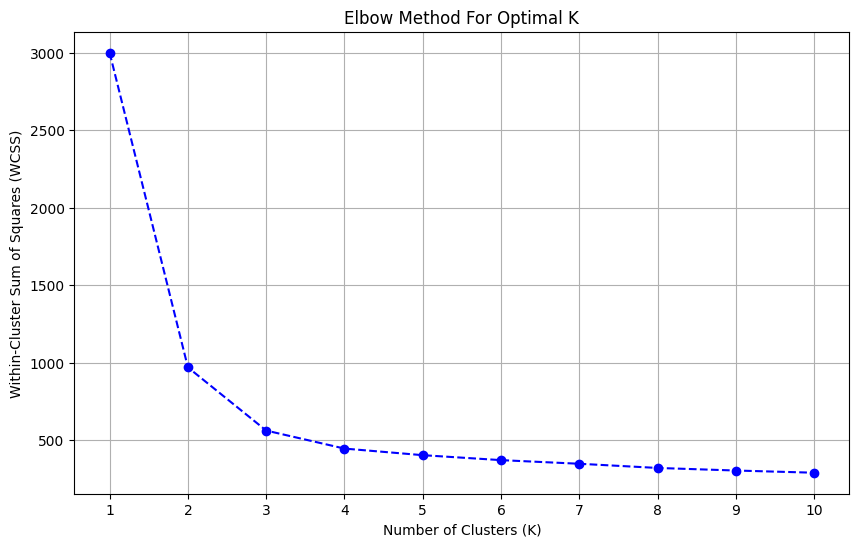

In [3]:
# Task 2: Choosing K — Elbow Method

# Calculate WCSS for K = 1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### Optimal K Selection
Based on the Elbow Method plot above, I have selected **K = 3** as the optimal number of clusters. 

Looking at the Within-Cluster Sum of Squares (WCSS), there is a massive drop in variance when moving from 1 to 2 clusters, and another significant drop from 2 to 3. However, after K = 3, the curve flattens out considerably, and the reductions in WCSS become marginal. This "elbow" at K=3 indicates that adding more than 3 clusters does not provide enough additional explanatory value to justify the increased complexity.

In [4]:
# Task 3: K-Means Clustering

# 1. Fit K-Means with the chosen K
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# 2. Add a 'cluster' column to the original dataframe
# We fit on the scaled data, but assign labels to the original dataframe
df_customers['cluster'] = kmeans.fit_predict(X_scaled)

# 3. Print the cluster centroids as a readable dataframe
# Grouping by the new cluster column and taking the mean gives us the business-readable centroids
cluster_centroids = df_customers.groupby('cluster').mean()

print("--- Cluster Centroids (Average Values per Cluster) ---")
display(cluster_centroids.round(2))

--- Cluster Centroids (Average Values per Cluster) ---


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,
0,24.68,14847.37,14.34,558.97,9.08,2.11
1,56.77,89413.33,2.53,5530.55,105.36,7.52
2,40.39,43340.73,8.19,2021.68,35.19,4.42


### Business Interpretation of Clusters
Based on the cluster centroids, we can define three distinct customer segments:

* **Cluster 0 (Young, Frequent Low-Spenders):** With an average age of ~25, these customers visit the store very frequently (over 14 times a month) but have a small basket size (~$559) and low annual spend. They buy from fewer categories and visited very recently. *Business Action:* Engage them with loyalty points, frequent small-ticket promotions, or cross-selling to increase their basket size.
* **Cluster 1 (Older, Infrequent High-Spenders):** With an average age of ~57, these customers visit rarely (~2.5 times a month) but spend heavily when they do (basket size ~$5,530) across many categories, leading to the highest annual spend. *Business Action:* Treat them as premium/VIP shoppers. Target them with exclusive, high-value occasion-based promotions or appointment shopping.
* **Cluster 2 (Middle-Aged, Moderate Mainstream Shoppers):** Averaging ~40 years old, this group sits right in the middle across all metrics. They visit moderately (~8 times a month) with a medium basket size (~$2,021) and average annual spend. *Business Action:* Use personalization to retain them and slowly expand the categories they shop in.

In [6]:
# Task 4: Dimensionality Reduction with PCA

from sklearn.decomposition import PCA
import pandas as pd

# 1. Apply PCA to reduce the data to 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 2. Print the explained variance ratio
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance Ratio: PC1 = {explained_variance[0]:.4f}, PC2 = {explained_variance[1]:.4f}")
print(f"Total Variance Explained: {sum(explained_variance):.4f}\n")

# 3. Print the feature loadings as a readable dataframe
# We drop the 'cluster' column to match the 6 original features PCA was trained on
original_features = df_customers.drop('cluster', axis=1).columns

loadings_df = pd.DataFrame(
    pca.components_, 
    columns=original_features, 
    index=['PC1', 'PC2']
)

print("--- PCA Feature Loadings ---")
display(loadings_df.round(4))

Explained Variance Ratio: PC1 = 0.8356, PC2 = 0.0557
Total Variance Explained: 0.8913

--- PCA Feature Loadings ---


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.4116,0.4215,-0.4104,0.4120,0.3786,0.4140
PC2,-0.2594,-0.0333,0.2083,-0.1954,0.9112,-0.1405


### Principal Component Interpretation
The PCA successfully reduced our 6-dimensional dataset into 2 principal components, which together explain over 89% of the total variance in the data.

* **PC1 (83.56% of Variance):** This component captures the primary underlying structure of our customer base. It has high positive loadings for `annual_spend`, `basket_size`, `age`, and `num_categories_purchased`, and a strong negative loading for `visits_per_month`. Therefore, PC1 represents the contrast between **Frequency and Spend/Age**. A high PC1 score indicates an older, infrequent shopper who spends heavily per trip. A low (negative) PC1 score indicates a young, highly frequent shopper with a small basket.
* **PC2 (5.57% of Variance):** This component is overwhelmingly dominated by a high positive loading for `days_since_last_visit` (0.9112). This dimension captures the **Recency** of the customer's last interaction, helping identify shoppers who haven't visited in a long time regardless of their spending habits.

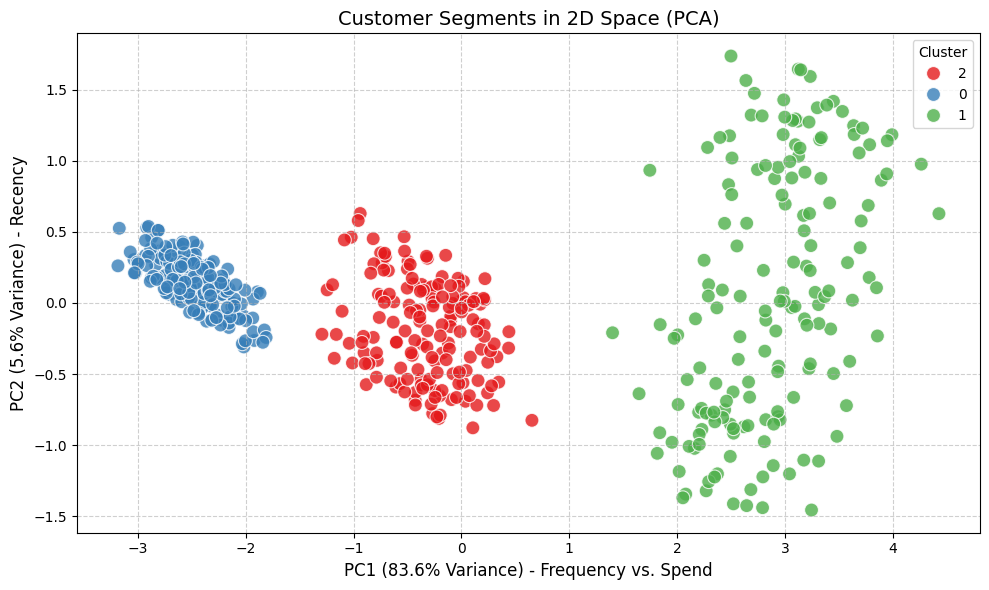

In [7]:
# Task 5: Cluster Visualisation

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Combine PCA data and cluster labels into a single dataframe for easy plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df_customers['cluster'].astype(str) # Convert to string for discrete colors


# 2. Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    data=pca_df, 
    palette='Set1', 
    s=100, 
    alpha=0.8
)

# 3. Add titles and labels
plt.title('Customer Segments in 2D Space (PCA)', fontsize=14)
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}% Variance) - Frequency vs. Spend', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}% Variance) - Recency', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()